In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from math import floor
from random import sample
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

sns.set(color_codes=True)
from lifelines.plotting import plot_lifetimes      # Lifeline package for the Survival Analysis
%pylab inline
figsize(12,6)

from lifelines import KaplanMeierFitter
kmf = KaplanMeierFitter()

Populating the interactive namespace from numpy and matplotlib


In [2]:
%run ./CVGI_MR_00_functions.ipynb

In [3]:
imports()

What is the source of the MOVEMENT data? (1=internet, 2=home Mac, 3=office Windows)3
What type of import is it? (1 = initial (only cases and movement), 2 = initial (full), 3 = data by week, 4 = merged datasets)4

IN
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1185852 entries, 0 to 1185851
Data columns (total 8 columns):
 #   Column           Non-Null Count    Dtype         
---  ------           --------------    -----         
 0   date             1185852 non-null  datetime64[ns]
 1   GADM_GID_2       1185852 non-null  object        
 2   mun_name         1185852 non-null  object        
 3   movement_change  1185852 non-null  float64       
 4   stay_put         1185852 non-null  float64       
 5   epi_week         1185852 non-null  object        
 6   ibge_code        1185852 non-null  int64         
 7   pop_2020         1185852 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(2), object(3)
memory usage: 72.4+ MB

+++++++++++++++++++++++++Movement Range

In [6]:
cases_by_epi_week_merged_clean = clean_cases_by_epi_week(cases_by_epi_week_merged)
cases_by_epi_week_merged_clean

,ibge_code,epi_week,acc_cases,acc_deaths,new_cases,new_deaths,pop_2019,epi_week_col,acc_cases_100k,acc_deaths_1mi,epi_week_date
0,1100015,2020.18,1,0,1,0,22945.0,2020.18,4.36,0.00,2020-05-10
1,1100015,2020.19,8,0,0,0,22945.0,2020.19,34.87,0.00,2020-05-17
2,1100015,2020.20,7,0,0,0,22945.0,2020.20,30.51,0.00,2020-05-24
3,1100015,2020.21,13,0,3,0,22945.0,2020.21,56.66,0.00,2020-05-31
4,1100015,2020.22,21,0,-1,0,22945.0,2020.22,91.52,0.00,2020-06-07
...,...,...,...,...,...,...,...,...,...,...,...
308030,5300108,2021.17,2316597,49512,6624,263,3015268.0,2021.17,76828.89,16420.43,2021-05-02
308031,5300108,2021.18,2358003,51165,5390,237,3015268.0,2021.18,78202.10,16968.64,2021-05-09
308032,5300108,2021.19,2396055,52654,5311,185,3015268.0,2021.19,79464.08,17462.46,2021-05-16
308033,5300108,2021.20,2433365,53799,5337,142,3015268.0,2021.20,80701.45,17842.20,2021-05-23


---

generating population data from the aggregate for one state in Brazil (let's pick RO, whichi is smaller)

In [4]:
%run ./CVGI_FB_functions.ipynb

In [4]:
uf = input(print('which UF are you interested in?',ibge_uf_dict))
df = cases_by_epi_week_merged_clean
cases_ro = df[(df['ibge_code'].str.startswith(uf))& (df['epi_week_date'] < ('2021-02-25'))]

which UF are you interested in? {11: 'RO', 12: 'AC', 13: 'AM', 14: 'RR', 15: 'PA', 16: 'AP', 17: 'TO', 21: 'MA', 22: 'PI', 23: 'CE', 24: 'RN', 25: 'PB', 26: 'PE', 27: 'AL', 28: 'SE', 29: 'BA', 31: 'MG', 32: 'ES', 33: 'RJ', 35: 'SP', 41: 'PR', 42: 'SC', 43: 'RS', 50: 'MS', 51: 'MT', 52: 'GO', 53: 'DF'}


In [5]:
cases_ro.new_deaths.sum()

2685

In [108]:
randSample = sorted(sample(range(2188),k=50))
cases_ro.loc[70:120][['ibge_code','acc_deaths','new_deaths']]

,ibge_code,acc_deaths,new_deaths
70,1100023,163,3
71,1100023,212,7
72,1100023,248,6
73,1100023,280,3
74,1100023,316,8
75,1100023,385,11
76,1100023,433,4
77,1100023,491,11
78,1100023,545,5
79,1100023,567,2


In [81]:
cases_ro_pop = pd.DataFrame({'ibge_code': pd.Series([], dtype='str'),'death_num': pd.Series([], dtype='float'),
                             'epi_week_date':pd.Series([], dtype='datetime64[D]')},index=cases_ro.ibge_code)
cases_ro_pop.death_num = 0
cases_ro_pop

ibge_code                object
death_num               float64
epi_week_date    datetime64[ns]
dtype: object

In [97]:
#c = 0
#opening up for each city
for id_code, val_code in enumerate(cases_ro.ibge_code):

    cases_ro_pop.ibge_code[id_code] = left(str(val_code),7)
#    if c > 500: break
    #opening for each new week
    for id_wk, val_wk in enumerate(cases_ro[cases_ro.ibge_code == val_code].epi_week_date):
        cases_ro_pop.epi_week_date[id_wk] = val_wk
#        if c > 500: break
#        c = c + 1
        #check if there are any cases, otherwise skip
        var_deaths = cases_ro[(cases_ro.ibge_code == val_code) & 
                              (cases_ro.epi_week_date == val_wk)].new_deaths.tolist()[0]
        if var_deaths > 0:
            for i in range(var_deaths):
                cases_ro_pop = cases_ro_pop.append({'ibge_code':val_code,'death_num':1,
                                                    'epi_week_date':val_wk}, ignore_index = True)
# THIS IS GENERATING WAY TOO MANY DEATHS... IT SHOULD BE 2685, NOT 126.279

In [98]:
cases_ro_pop

,ibge_code,death_num,epi_week_date
0,1100015,0,2020-05-31
1,1100015,0,2020-06-07
2,1100015,0,2020-06-14
3,1100015,0,2020-06-21
4,1100015,0,2020-06-28
...,...,...,...
128462,1101807,1,2021-01-10
128463,1101807,1,2021-01-24
128464,1101807,1,2021-01-24
128465,1101807,1,2021-02-07


In [102]:
cases_ro_pop.death_num.sum()

126279

---

creating an even smaller sample: one city only

In [10]:
cases_test = cases_by_epi_week_merged_clean[cases_by_epi_week_merged_clean.ibge_code == "1100023"][['epi_week','new_deaths']]

In [11]:
cases_test

,epi_week,new_deaths
57,2020.15,0
58,2020.16,0
59,2020.17,0
60,2020.18,0
61,2020.19,0
62,2020.20,0
63,2020.21,3
64,2020.22,1
65,2020.23,1
66,2020.24,4


In [12]:
cases_teste_pop = pd.DataFrame({'death_num': pd.Series([], dtype='float'),
                             'epi_week_date':pd.Series([], dtype='float')}                             )
cases_teste_pop.death_num = 0
cases_teste_pop

,death_num,epi_week_date


In [13]:
cases_test.new_deaths.sum()

427

In [14]:
c = 0
for id_wk, val_wk in enumerate(cases_test.epi_week):
        cases_teste_pop.epi_week_date[id_wk] = val_wk
        c+=1
#        if c > 500: break
#        c = c + 1
        #check if there are any cases, otherwise skip
        var_deaths = cases_test[(cases_test.epi_week == val_wk)].new_deaths.tolist()[0]
        #print(var_deaths,val_wk)
        #wk = float(id_wk)
        if var_deaths > 0:
            for i in range(var_deaths):
        #        print(val_wk,var_deaths, i)
                cases_teste_pop = cases_teste_pop.append({'death_num':1,'epi_week_date':c}, ignore_index = True)
cases_teste_pop

,death_num,epi_week_date
0,1,7.0
1,1,7.0
2,1,7.0
3,1,8.0
4,1,9.0
...,...,...
422,1,59.0
423,1,59.0
424,1,60.0
425,1,60.0


In [18]:
cases_teste_pop.index

RangeIndex(start=0, stop=427, step=1)

In [22]:
print(cases_teste_pop.epi_week_date.min(),cases_teste_pop.epi_week_date.max())

7.0 2021.21


In [24]:
cases_teste_pop = cases_teste_pop[cases_teste_pop.epi_week_date < 70]

In [25]:
print(cases_teste_pop.epi_week_date.min(),cases_teste_pop.epi_week_date.max())

7.0 60.0


In [86]:
cases_test_pop.dtypes

death_num          int64
epi_week_date    float64
dtype: object

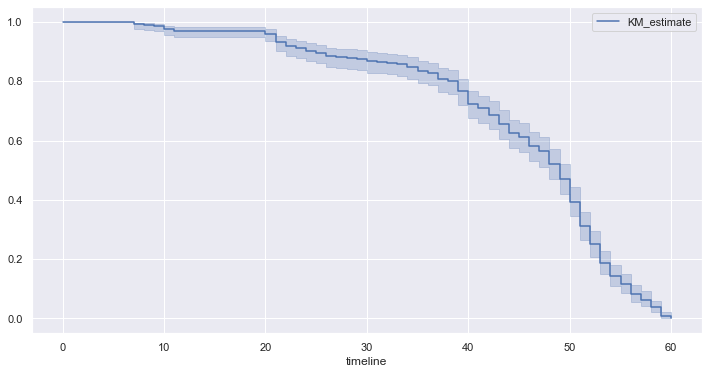

In [27]:
kmf2 = KaplanMeierFitter()

T = cases_teste_pop['epi_week_date']     ## time to event
E = cases_teste_pop['death_num']      ## variable indicating the event

#cohorts = df['StreamingTV']
#i1 = (cohorts == 'No')
#i2 = (cohorts == 'Yes')

kmf2.fit(T,E)
a1 = kmf2.plot()
#kmf1.fit(T[i2], E[i2], label='Subscribed Streaming TV')
#kmf2.plot(ax=a1)
plt.show()